<a href="https://colab.research.google.com/github/laxmijin11-cyber/MACHINE-LEARNING/blob/main/Decision_Tree/2_Pruning_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [185]:
# Decision Tree Implementation-Post Pruning and Pre Pruning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [186]:
from sklearn.datasets import load_iris
iris=load_iris()

In [187]:
iris['data']

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

iris.data is a 2D NumPy array, not a pandas DataFrame

iris: numpy.ndarray

In [188]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [189]:
print(iris['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In load_iris(), DESCR is a key in the dictionary-like object that stores the description of the dataset.

In [190]:
print(iris['target'])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [191]:
## Independent Features
x=pd.DataFrame(iris['data'],columns=['sepal length','sepal width','petal length','petal width'])

In [192]:
x

,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [193]:
#dependent feature
y=iris['target']
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [194]:
# train_test_split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=10)

In [195]:
from sklearn.tree import DecisionTreeClassifier
treeclassifier=DecisionTreeClassifier()

In [196]:
treeclassifier.fit(x_train,y_train)
y_pred=treeclassifier.predict(x_test)
y_pred

array([1, 2, 0, 1, 0, 1, 1, 1, 0, 1, 1, 2, 1, 0, 0, 2, 1, 0, 0, 0, 2, 2,
       2, 0, 1, 0, 1, 1, 1, 2])

In [197]:
type(iris['data'])

numpy.ndarray

<Figure size 1000x2000 with 0 Axes>

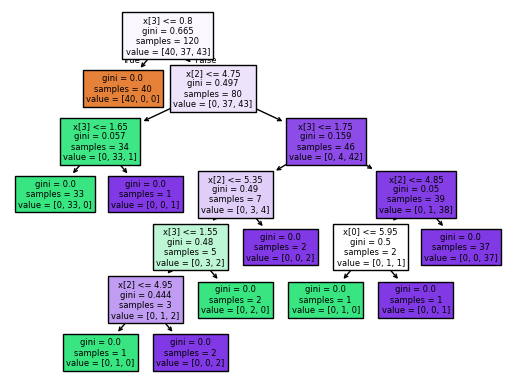

<Figure size 1000x2000 with 0 Axes>

In [198]:
#Visualize the Decision Tree
from sklearn import tree
tree.plot_tree(treeclassifier,filled=True)
plt.figure(figsize=(10,20))

In [199]:
# Post Pruning
treemodel=DecisionTreeClassifier(max_depth=2)
treemodel.fit(x_train,y_train)
y_pred=treemodel.predict(x_test)

In [200]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))


[[10  0  0]
 [ 0 11  2]
 [ 0  0  7]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.85      0.92        13
           2       0.78      1.00      0.88         7

    accuracy                           0.93        30
   macro avg       0.93      0.95      0.93        30
weighted avg       0.95      0.93      0.93        30

0.9333333333333333


In [201]:
# Decision Tree Pre-pruning and Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
# param={
#     'criterion':['gini','entropy','log_loss'],
#     'splitter':['best','random'],
#     'max_depth':[1,2,3,4,5],
#     'max_features':['auto','sqrt','log2']
# }

param_dist={
    'criterion':['gini','entropy','log_loss'],
    'max_depth':[1,3,5,7],
    'max_features':['auto','sqrt','log2'],
    'min_samples_split':[2,4,6,8]
}

# Decision Tree Hyperparameters

---

## What Each Parameter Does

| Parameter | Values | What It Controls |
|-----------|--------|------------------|
| **criterion** | `gini`, `entropy`, `log_loss` | How to measure split quality (gini = default, entropy = info gain) |
| **splitter** | `best`, `random` | Best = tries all splits, random = tries few (faster) |
| **max_depth** | `1,2,3,4,5` | Max tree depth (prevents overfitting) |
| **max_features** | `'auto'`, `'sqrt'`, `'log2'` | How many features to consider at each split |

---

##  Why Tune Them?

| Parameter | Effect |
|-----------|--------|
| **criterion** | Changes how tree decides splits |
| **splitter** | Speed vs accuracy trade-off |
| **max_depth** | Deeper = more overfitting |
| **max_features** | Lower = faster, may reduce overfitting |

---

## One Line

**These parameters control how your decision tree grows – tune them to avoid overfitting and improve accuracy.**

In [202]:
grid=GridSearchCV(treeclassifier,param_grid=param_dist,cv=5,scoring='accuracy')

In [203]:
import warnings
warnings.filterwarnings('ignore')

In [204]:
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 3, 5, 7],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_split': [2, 4, 6, 8]},
             scoring='accuracy')

In [205]:
y_pred=grid.predict(x_test)

In [206]:
grid.best_params_

{'criterion': 'log_loss',
 'max_depth': 3,
 'max_features': 'sqrt',
 'min_samples_split': 8}

# Hyperparameter

---

##  What These Values Mean

| Parameter | Value | Meaning |
|-----------|-------|---------|
| **criterion** | `'log_loss'` | Uses log loss (entropy) to measure split quality |
| **max_depth** | `3` | Tree can only grow 3 levels deep (controls overfitting) |
| **max_features** | `'sqrt'` | Considers √n features at each split (n = total features) |
| **min_samples_split** | (not shown) | Minimum samples required to split a node |

---

In [207]:
grid.best_score_

np.float64(0.9583333333333334)

grid.best_score_ is the result of scoring='accuracy' – same metric, averaged across CV folds.

grid.best_score_ returns the average cross-validation score using the metric you specified in scoring='accuracy'.

Hence, grid.best_score_ and scoring='accuracy' in GridSearchCV are same

In [208]:
y_pred

array([1, 2, 0, 1, 0, 1, 2, 1, 0, 1, 1, 2, 1, 0, 0, 2, 1, 0, 0, 0, 2, 2,
       2, 0, 1, 0, 1, 1, 2, 2])

In [209]:
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[10  0  0]
 [ 0 11  2]
 [ 0  0  7]]
0.9333333333333333
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.85      0.92        13
           2       0.78      1.00      0.88         7

    accuracy                           0.93        30
   macro avg       0.93      0.95      0.93        30
weighted avg       0.95      0.93      0.93        30



## Difference

| | `accuracy_score(y_test, y_pred)` | `scoring='accuracy'` in GridSearchCV |
|--|----------------------------------|--------------------------------------|
| **When** | After training (on test set) | During CV (on validation folds) |
| **Data** | Same test set | Different validation sets each fold |
| **Purpose** | Final evaluation | Model selection |

---

## One Line

**`accuracy_score` = final check. `scoring='accuracy'` = guide for choosing best model.** 🚀

#  RandomizedSearchCV

---

## What It Means

**RandomizedSearchCV tries random combinations of hyperparameters instead of ALL combinations.**

- `GridSearchCV` = tries EVERY combination (exhaustive)
- `RandomizedSearchCV` = tries RANDOM combinations (sampling)

---

## Comparison

| | GridSearchCV | RandomizedSearchCV |
|--|--------------|---------------------|
| **Method** | Tries all combinations | Tries random combinations |
| **Time** | Slow (exhaustive) | Fast (sampling) |
| **Best for** | Small param grids | Large param grids |
| **Guaranteed best?** | Yes (finds global optimum) | No (may miss best) |

---

## Code Example

```python
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(),
    param_distributions=param_dist,
    n_iter=20,  # ← tries 20 random combos (not all 4×4×3=48)
    cv=5,
    scoring='accuracy'
)

random_search.fit(X_train, y_train)
```

---

## One Line

**Use RandomizedSearchCV when you have MANY hyperparameters – it's faster but may not find absolute best.**

In [210]:
from sklearn.model_selection import RandomizedSearchCV
param_dist={
    'criterion':['gini','entropy','log_loss'],
    'max_depth':[1,3,5,7],
    'max_features':['auto','sqrt','log2'],
    'min_samples_split':[2,4,6,8]
}

random=RandomizedSearchCV(treeclassifier,param_dist,n_iter=20,cv=5,scoring='accuracy')

In [211]:
random.fit(x_train,y_train)
y_pred=random.predict(x_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[10  0  0]
 [ 0 11  2]
 [ 0  0  7]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.85      0.92        13
           2       0.78      1.00      0.88         7

    accuracy                           0.93        30
   macro avg       0.93      0.95      0.93        30
weighted avg       0.95      0.93      0.93        30

0.9333333333333333


In [212]:
random.best_params_

{'min_samples_split': 2,
 'max_features': 'sqrt',
 'max_depth': 3,
 'criterion': 'log_loss'}

In [213]:
random.best_score_

np.float64(0.9416666666666667)

Step 1: Create Decision Tree model

Step 2: Apply RandomizedSearchCV to find best hyperparameters

Step 3: Use best model to predict

In [214]:
# This is Pruning concept in Decision tree calssifier.....